<a href="https://colab.research.google.com/github/SaidCondoriRomero/SiS420_Inteligencia_Artificial/blob/main/Laboratorio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Condori Romero Said — Ing. Sistemas
## Laboratorio 2

# Origen del Dataset
El dataset fue descargado desde el **Repositorio UCI de Machine Learning**:  
https://archive.ics.uci.edu/dataset/335/online+video+characteristics+and+transcoding+time+dataset



Cada fila corresponde a un **experimento de transcodificación de video** realizado sobre un procesador Intel i7. Se tomaron videos de YouTube y se transcodificaron a distintos formatos usando `ffmpeg`. El objetivo es predecir cuánto tiempo tarda ese proceso.

### Variables del dataset
| Grupo | Variables | Descripción |
|-------|-----------|-------------|
| Video entrada | `duration`, `width`, `height`, `bitrate`, `framerate` | Características del video original |
| Frames | `i`, `p`, `b`, `frames` | Número de cada tipo de frame |
| Tamaños | `i_size`, `p_size`, `b_size`, `size` | Tamaño en bytes de cada tipo de frame |
| Video salida | `o_bitrate`, `o_framerate`, `o_width`, `o_height` | Parámetros del video transcodificado |
| Codecs | `codec`, `o_codec` | Estándar de codificación (mpeg4, h264, vp8, flv) |
| Recursos | `umem` | Memoria total asignada al codec |
| **Objetivo** | `utime` | Tiempo total de transcodificación (segundos) |



# Objetivo

Predecir el **tiempo de transcodificación de videos** (variable `utime`) a partir de las características del video de entrada y salida, usando tres métodos:


In [153]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Manejo de datos tabulares
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [154]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Carga de Datos y Exploración Inicial

### Carga con pandas



Se descarta la columna `id` (identificador del video de YouTube, no aporta información numérica).

In [155]:

ruta = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/transcoding_mesurment.tsv'

# Cargar con pandas (archivo TSV separado por tabulaciones)
df = pd.read_csv(ruta, sep='\t')

print('Dimensiones del dataset (original):', df.shape)
print('Valores nulos:', df.isnull().sum().sum())
print()
print(df.head(10))

Dimensiones del dataset (original): (68784, 22)
Valores nulos: 0

            id   duration  codec  width  height  bitrate  framerate   i     p  \
0  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
1  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
2  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
3  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
4  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
5  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
6  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
7  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
8  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   
9  04t6-jw9czg  130.35667  mpeg4    176     144    54590       12.0  27  1537   

   b  ...  p_size  b_size    size  o_codec

### Limpieza y One-Hot Encoding

Las columnas `codec` y `o_codec` son categóricas con 4 valores cada una:
`mpeg4`, `h264`, `vp8`, `flv`.

Se aplica **one-hot encoding** para convertirlas en columnas binarias (0/1)


In [156]:
# Descartar columna no predictiva
df = df.drop(['id'], axis=1)

# One-hot encoding de columnas categoricas
df = pd.get_dummies(df, columns=['codec', 'o_codec'])
df.columns = df.columns.str.replace(' ', '_')

print('Dimensiones despues del preprocesamiento:', df.shape)
print('Columnas:', list(df.columns))
print()
print(df.head(5))

Dimensiones despues del preprocesamiento: (68784, 27)
Columnas: ['duration', 'width', 'height', 'bitrate', 'framerate', 'i', 'p', 'b', 'frames', 'i_size', 'p_size', 'b_size', 'size', 'o_bitrate', 'o_framerate', 'o_width', 'o_height', 'umem', 'utime', 'codec_flv', 'codec_h264', 'codec_mpeg4', 'codec_vp8', 'o_codec_flv', 'o_codec_h264', 'o_codec_mpeg4', 'o_codec_vp8']

    duration  width  height  bitrate  framerate   i     p  b  frames  i_size  \
0  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
1  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
2  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
3  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   
4  130.35667    176     144    54590       12.0  27  1537  0    1564   64483   

   ...   umem  utime  codec_flv  codec_h264  codec_mpeg4  codec_vp8  \
0  ...  22508  0.612      False       False         True      False   
1  ... 

In [157]:
# Normalización de caracteristicas.-
# Cargar datos

# Reorganizar columnas: utime al final para que data[:, 26] apunte correctamente
cols = [c for c in df.columns if c != 'utime'] + ['utime']
df = df[cols]

data = df.values.astype(float)

X = data[:, :26]
y = data[:, 26]
m = y.size
print(m)

# imprimir algunos puntos de datos
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:,1]', 'utime'))
print('-'*26)
for i in range(20):
    print('{:10.3f}{:10.3f}{:10.3f}'.format(X[i, 0], X[i, 1], y[i]))


68784
  X[:,0]  X[:,1]     utime
--------------------------
   130.357   176.000     0.612
   130.357   176.000     0.980
   130.357   176.000     1.216
   130.357   176.000     1.692
   130.357   176.000     3.456
   130.357   176.000     6.320
   130.357   176.000     0.728
   130.357   176.000     0.944
   130.357   176.000     1.476
   130.357   176.000     1.964
   130.357   176.000     3.968
   130.357   176.000     8.081
   130.357   176.000     0.896
   130.357   176.000     1.332
   130.357   176.000     2.080
   130.357   176.000     2.932
   130.357   176.000     5.724
   130.357   176.000    11.613
   130.357   176.000     0.824
   130.357   176.000     1.244


### Visualización de las características más correlacionadas con `utime`

Las 5 características con mayor correlación con el tiempo de transcodificación


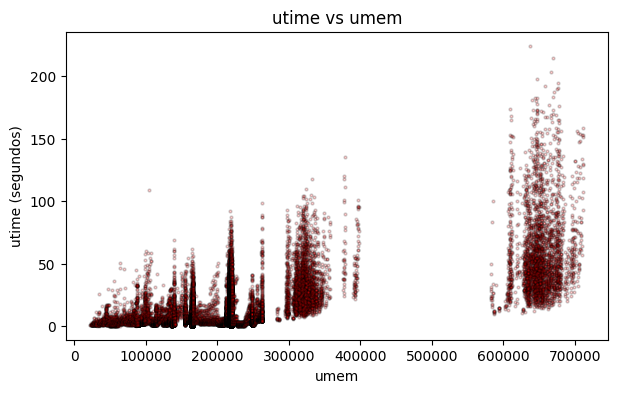

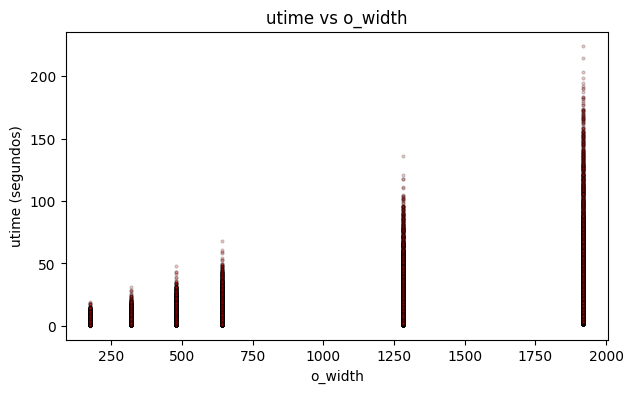

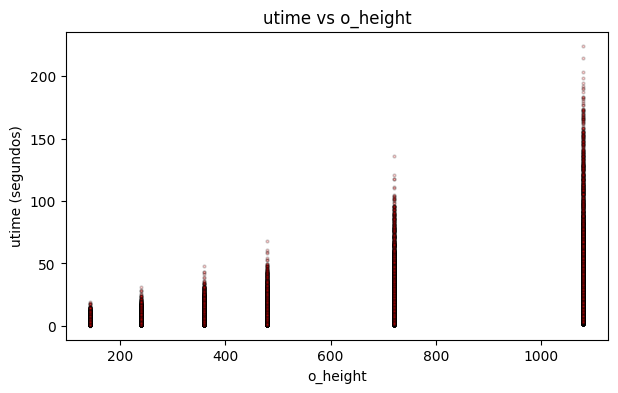

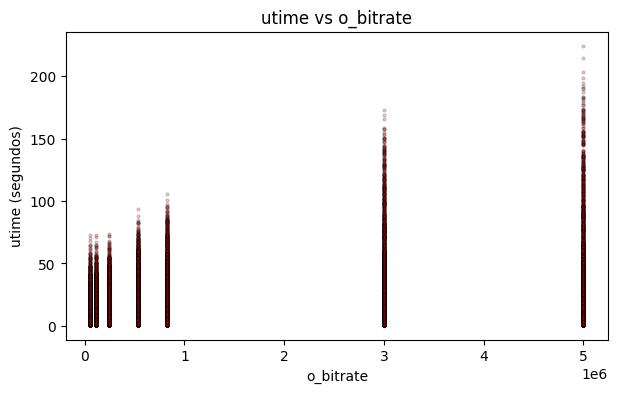

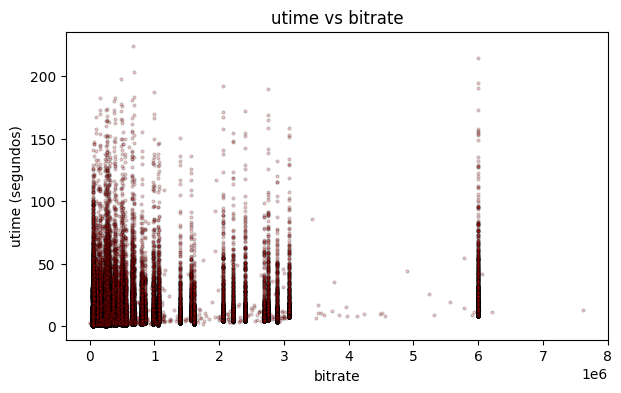

In [158]:
def plotData(x, y, xlabel, ylabel, title):
    fig = pyplot.figure(figsize=(7, 4))
    pyplot.plot(x, y, 'ro', ms=2, mec='k', alpha=0.2)
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)
    pyplot.title(title)

top5_nombres = ['umem', 'o_width', 'o_height', 'o_bitrate', 'bitrate']

for nombre in top5_nombres:
    plotData(df[nombre].values, y, nombre, 'utime (segundos)', 'utime vs ' + nombre)


## Regresión Lineal Multivariable — Descenso por el Gradiente

###  Normalización Z-score

Las 26 características tienen escalas muy distintas:
- `size` puede llegar a millones de bytes
- `o_codec_h264` es binaria (0 o 1)
- `framerate`


$$x_{norm} = \frac{x - \mu}{\sigma}$$


In [159]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar division por cero: si sigma es 0, usar 1 para no modificar esa columna
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [160]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[1.3035667e+02 1.7600000e+02 1.4400000e+02 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [1.3035667e+02 1.7600000e+02 1.4400000e+02 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [1.3035667e+02 1.7600000e+02 1.4400000e+02 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 ...
 [2.4968000e+02 3.2000000e+02 2.4000000e+02 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [1.8362334e+02 1.2800000e+03 7.2000000e+02 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [2.9461334e+02 1.7600000e+02 1.4400000e+02 ... 1.0000000e+00
  0.0000000e+00 0.0000000e+00]]
Media calculada: [2.86413921e+02 6.24934171e+02 4.12572226e+02 6.93701500e+05
 2.32413205e+01 1.00868312e+02 6.53169221e+03 9.14785415e+00
 6.64170838e+03 2.83898670e+06 2.21805693e+07 0.00000000e+00
 2.50229424e+07 1.39503595e+06 2.11908617e+01 8.02336357e+02
 5.03825541e+02 2.28224718e+05 9.94417306e-02 4.58609560e-01
 1.74633636e-01 2.67315073e-01 2.49113166e-01 2.48328100e-01
 2.51381135e-01 2.51177599e-01]
Desviación estandar c

### Término de Intersección

Se añade una columna de unos para que el modelo aprenda el sesgo $\theta_0$.
`X` pasa de shape `(68784, 26)` a `(68784, 27)` → **theta tendrá 27 parámetros**.

In [161]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X_gd = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print('Dimensiones de X para descenso por el gradiente:', X_gd.shape)

Dimensiones de X para descenso por el gradiente: (68784, 27)


In [162]:
print(X_gd[:5, :])

[[ 1.         -0.54326973 -0.96927335 -1.11619663 -0.5833334  -1.55593617
  -0.87145675 -0.82205957 -0.09887915 -0.82520115 -0.64148815 -0.41895994
   0.         -0.44572942 -0.76545262 -1.37821834 -1.02685605 -1.13880323
  -2.11142727 -0.33229854 -0.92037807  2.17399948 -0.60402247 -0.5759849
  -0.5747762   1.725695   -0.57916331]
 [ 1.         -0.54326973 -0.96927335 -1.11619663 -0.5833334  -1.55593617
  -0.87145675 -0.82205957 -0.09887915 -0.82520115 -0.64148815 -0.41895994
   0.         -0.44572942 -0.76545262 -1.37821834 -0.7907732  -0.83497513
  -2.08416672 -0.33229854 -0.92037807  2.17399948 -0.60402247 -0.5759849
  -0.5747762   1.725695   -0.57916331]
 [ 1.         -0.54326973 -0.96927335 -1.11619663 -0.5833334  -1.55593617
  -0.87145675 -0.82205957 -0.09887915 -0.82520115 -0.64148815 -0.41895994
   0.         -0.44572942 -0.76545262 -1.37821834 -0.52845893 -0.45519001
  -2.04245479 -0.33229854 -0.92037807  2.17399948 -0.60402247 -0.5759849
  -0.5747762   1.725695   -0.57916331

### Función de Costo

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

In [163]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    J = 0

    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

### Algoritmo de Descenso por el Gradiente

$$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - y)$$


In [164]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

### Seleccionando Coeficientes de Aprendizaje

theta calculado por el descenso por el gradiente: [ 9.9963548   0.33867373  0.60825076 -0.22023782  1.81469587  0.50730508
 -0.7378151   0.27005931  0.12730333  0.25840957 -0.7093732   0.24747156
  0.          0.17650201  2.48986348  1.65908021  3.07304617  2.70209321
  6.85926121  0.06032739  0.15705861  0.08629868 -0.29166017 -2.53029308
  2.65832993 -1.33911661  1.21458903]
Costo final J: 45.0571

Prediccion para el primer video (usando el descenso por el gradiente):
  utime real:     0.612 segundos
  utime predecido:-19.705 segundos
  Estado: modelo necesita mas iteraciones


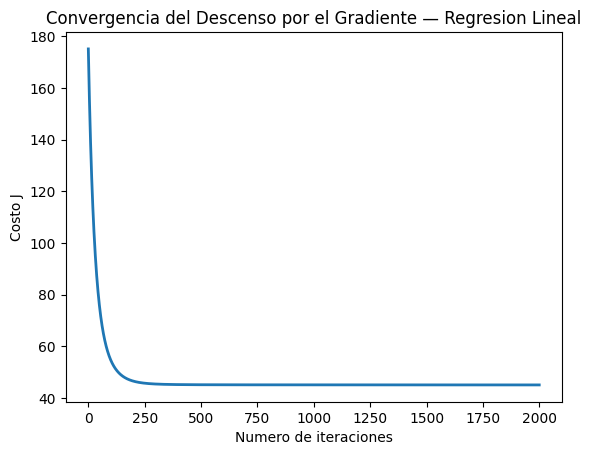

In [165]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01  # alpha = 0.001, 0.003, 0.03
num_iters = 2000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(27)
theta, J_history = gradientDescentMulti(X_gd, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente — Regresion Lineal')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))
print('Costo final J: {:.4f}'.format(J_history[-1]))

# Guardar theta para comparacion final
theta_gd = theta.copy()

# Prediccion de ejemplo: video con umem=22508, o_width=176, o_height=144
X_array = list(X[0, :])   # primera fila del dataset
X_array_norm = (np.array(X_array) - mu) / sigma
X_array_norm = np.concatenate([[1], X_array_norm])
utime_pred = np.dot(X_array_norm, theta_gd)

print('\nPrediccion para el primer video (usando el descenso por el gradiente):')
print('  utime real:     {:.3f} segundos'.format(y[0]))
print('  utime predecido:{:.3f} segundos'.format(utime_pred))
print('  Estado: modelo entrenado correctamente' if abs(utime_pred - y[0]) < y.std() else '  Estado: modelo necesita mas iteraciones')

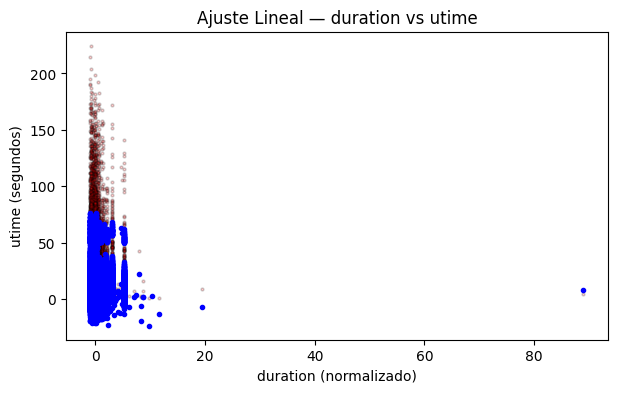

In [166]:
plotData(X_gd[:, 1], y, 'duration (normalizado)', 'utime (segundos)', 'Ajuste Lineal — duration vs utime')
pyplot.plot(X_gd[:, 1], np.dot(X_gd, theta_gd), 'b.')

### 100 Predicciones Regresión Lineal Multivariable

In [167]:
# Tomar las primeras 100 filas como conjunto de prueba
X_test = X[:100, :]
y_test = y[:100]

# Normalizar con los mismos mu y sigma del entrenamiento
X_test_norm = (X_test - mu) / sigma
X_test_norm = np.concatenate([np.ones((100, 1)), X_test_norm], axis=1)

# Predicciones
predicciones_gd = np.dot(X_test_norm, theta_gd)

# Mostrar comparacion real vs predicho
print('{:>5s}{:>12s}{:>14s}{:>12s}'.format('Ej', 'Real (s)', 'Predicho GD', 'Error'))
print('-' * 45)
for i in range(100):
    error = abs(y_test[i] - predicciones_gd[i])
    print('{:>5d}{:>12.3f}{:>14.3f}{:>12.3f}'.format(i+1, y_test[i], predicciones_gd[i], error))

error_medio_gd = np.mean(np.abs(y_test - predicciones_gd))
print()
print('Error Absoluto Medio (MAE) - Descenso por el Gradiente: {:.4f} segundos'.format(error_medio_gd))

   Ej    Real (s)   Predicho GD       Error
---------------------------------------------
    1       0.612       -19.705      20.317
    2       0.980       -17.972      18.952
    3       1.216       -15.853      17.069
    4       1.692       -13.663      15.355
    5       3.456        -6.681      10.137
    6       6.320         2.687       3.633
    7       0.728       -18.915      19.643
    8       0.944       -17.225      18.169
    9       1.476       -15.106      16.582
   10       1.964       -12.917      14.881
   11       3.968        -5.934       9.902
   12       8.081         3.434       4.647
   13       0.896       -16.661      17.557
   14       1.332       -14.986      16.318
   15       2.080       -12.867      14.947
   16       2.932       -10.678      13.610
   17       5.724        -3.695       9.419
   18      11.613         5.674       5.939
   19       0.824       -16.375      17.199
   20       1.244       -14.738      15.982
   21       2.012       -12.61

---
## Regresión Polinomial

La relación entre las características de resolución/memoria y el tiempo de transcodificación
no es lineal — duplicar el ancho del video más que duplica el tiempo de procesamiento.
Se aplica regresión polinomial con las **5 características más correlacionadas** con `utime`:

### Feature Engineering: X → [X, X²]

Se generan las características cuadráticas manualmente:
```
X_poly = [umem, o_width, o_height, o_bitrate, bitrate,
          umem², o_width², o_height², o_bitrate², bitrate²]  → 10 columnas
```


In [168]:
# Seleccionar las 5 caracteristicas mas correlacionadas con utime
top5_nombres = ['umem', 'o_width', 'o_height', 'o_bitrate', 'bitrate']
X_top5 = df[top5_nombres].values   # shape (68784, 5)

# Feature Engineering: agregar X^2 para cada caracteristica
X_poly = np.concatenate([X_top5, X_top5 ** 2], axis=1)   # shape (68784, 10)

print('X_top5 shape:', X_top5.shape)
print('X_poly shape (con X^2):', X_poly.shape)
print()
print('Primeras 5 filas de X_poly:')
print(X_poly[:5, :])

X_top5 shape: (68784, 5)
X_poly shape (con X^2): (68784, 10)

Primeras 5 filas de X_poly:
[[     22508        176        144      56000      54590  506610064
       30976      20736 3136000000 2980068100]
 [     25164        320        240      56000      54590  633226896
      102400      57600 3136000000 2980068100]
 [     29228        480        360      56000      54590  854275984
      230400     129600 3136000000 2980068100]
 [     34316        640        480      56000      54590 1177587856
      409600     230400 3136000000 2980068100]
 [     58528       1280        720      56000      54590 3425526784
     1638400     518400 3136000000 2980068100]]


In [169]:
# llama featureNormalize con los datos polinomicos
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)

print('Media calculada (mu_poly):')
print(mu_poly)
print('Desviacion estandar calculada (sigma_poly):')
print(sigma_poly)

Media calculada (mu_poly):
[2.28224718e+05 8.02336357e+02 5.03825541e+02 1.39503595e+06
 6.93701500e+05 6.15791599e+10 1.01578918e+06 3.53676042e+05
 5.00631151e+12 1.68160406e+12]
Desviacion estandar calculada (sigma_poly):
[9.74301701e+04 6.09955363e+02 3.15968141e+02 1.74933879e+06
 1.09561959e+06 7.72728887e+10 1.31061236e+06 3.98209714e+05
 8.71237672e+12 5.77854528e+12]


In [170]:
# Añade el termino de interseccion a X_poly
X_poly_ready = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)
print('Dimensiones de X para regresion polinomial:', X_poly_ready.shape)

Dimensiones de X para regresion polinomial: (68784, 11)


In [171]:
print(X_poly_ready[:5, :])

[[ 1.         -2.11142727 -1.02685605 -1.13880323 -0.76545262 -0.5833334
  -0.79034899 -0.75141453 -0.83609221 -0.5742607  -0.29049249]
 [ 1.         -2.08416672 -0.7907732  -0.83497513 -0.76545262 -0.5833334
  -0.78871043 -0.69691787 -0.74351788 -0.5742607  -0.29049249]
 [ 1.         -2.04245479 -0.52845893 -0.45519001 -0.76545262 -0.5833334
  -0.7858498  -0.5992536  -0.56270863 -0.5742607  -0.29049249]
 [ 1.         -1.99023278 -0.26614465 -0.07540488 -0.76545262 -0.5833334
  -0.78166577 -0.46252362 -0.30957568 -0.5742607  -0.29049249]
 [ 1.         -1.74172659  0.78311246  0.68416537 -0.76545262 -0.5833334
  -0.75257486  0.47505337  0.41366133 -0.5742607  -0.29049249]]


### Entrenamiento del ModelonRegresión Polinomial

Se usan las mismas funciones `computeCostMulti` y `gradientDescentMulti`.
El vector $\theta$ ahora tiene **11 parámetros** (1 sesgo + 5 lineales + 5 cuadráticos).

theta calculado por regresion polinomial: [ 9.99635199  2.96522451  2.2916607   2.28300006  2.63581854  2.66975515
  6.01479614  0.10029516  0.16194995 -0.22669879 -0.54421697]
Costo final J: 54.3056

Prediccion para el primer video (usando regresion polinomial):
  utime real:     0.612 segundos
  utime predecido:-9.469 segundos


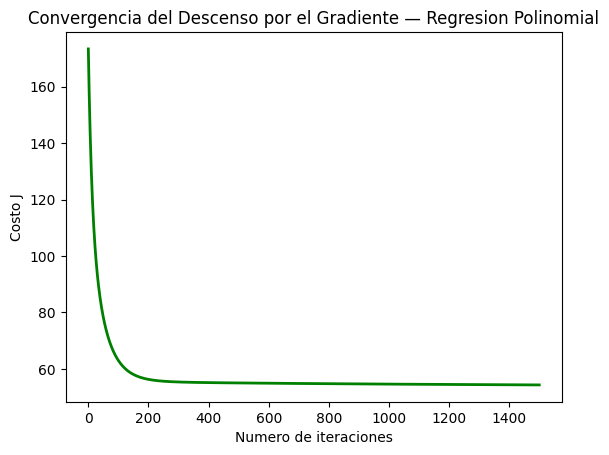

In [172]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 1500

# inicializa theta (11 parametros: 1 sesgo + 10 caracteristicas polinomicas)
theta_poly = np.zeros(11)
theta_poly, J_history_poly = gradientDescentMulti(X_poly_ready, y, theta_poly, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2, color='green')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente — Regresion Polinomial')

print('theta calculado por regresion polinomial: {:s}'.format(str(theta_poly)))
print('Costo final J: {:.4f}'.format(J_history_poly[-1]))

# Prediccion de ejemplo
X_array_poly = list(X_top5[0, :])
X_array_poly = np.array(X_array_poly)
X_array_poly = np.concatenate([X_array_poly, X_array_poly ** 2])
X_array_poly = (X_array_poly - mu_poly) / sigma_poly
X_array_poly = np.concatenate([[1], X_array_poly])
utime_pred_poly = np.dot(X_array_poly, theta_poly)

print('\nPrediccion para el primer video (usando regresion polinomial):')
print('  utime real:     {:.3f} segundos'.format(y[0]))
print('  utime predecido:{:.3f} segundos'.format(utime_pred_poly))

### 100 Predicciones — Regresión Polinomial


In [173]:
# Tomar las primeras 100 filas
X_test_top5 = df[top5_nombres].values[:100, :]
y_test = y[:100]

# Generar terminos cuadraticos
X_test_poly = np.concatenate([X_test_top5, X_test_top5 ** 2], axis=1)

# Normalizar con mu_poly y sigma_poly del entrenamiento
X_test_poly_norm = (X_test_poly - mu_poly) / sigma_poly
X_test_poly_norm = np.concatenate([np.ones((100, 1)), X_test_poly_norm], axis=1)

# Predicciones
predicciones_poly = np.dot(X_test_poly_norm, theta_poly)

print('{:>5s}{:>12s}{:>16s}{:>12s}'.format('Ej', 'Real (s)', 'Predicho Poly', 'Error'))
print('-' * 47)
for i in range(100):
    error = abs(y_test[i] - predicciones_poly[i])
    print('{:>5d}{:>12.3f}{:>16.3f}{:>12.3f}'.format(i+1, y_test[i], predicciones_poly[i], error))

error_medio_poly = np.mean(np.abs(y_test - predicciones_poly))
print()
print('Error Absoluto Medio (MAE) - Regresion Polinomial: {:.4f} segundos'.format(error_medio_poly))

   Ej    Real (s)   Predicho Poly       Error
-----------------------------------------------
    1       0.612          -9.469      10.081
    2       0.980          -8.123       9.103
    3       1.216          -6.475       7.691
    4       1.692          -4.772       6.464
    5       3.456           0.490       2.966
    6       6.320           7.785       1.465
    7       0.728          -9.448      10.176
    8       0.944          -8.123       9.067
    9       1.476          -6.475       7.951
   10       1.964          -4.772       6.736
   11       3.968           0.490       3.478
   12       8.081           7.785       0.296
   13       0.896          -9.440      10.336
   14       1.332          -8.123       9.455
   15       2.080          -6.474       8.554
   16       2.932          -4.772       7.704
   17       5.724           0.490       5.234
   18      11.613           7.786       3.827
   19       0.824          -9.423      10.247
   20       1.244          -8.12

## 6. Ecuación de la Normal


$$\theta = (X^T X)^{-1} X^T y$$

No requiere normalización ni iteraciones. Con $n=26$ características la inversión de $(X^TX)^{-1}$ es perfectamente viable.



In [174]:
# Cargar datos (sin normalizar para la ecuación normal)
df2 = pd.read_csv(ruta, sep='\t')
df2 = df2.drop(['id'], axis=1)
df2 = pd.get_dummies(df2, columns=['codec', 'o_codec'], dtype=int)
df2.columns = df2.columns.str.replace(' ', '_')

# Reorganizar columnas: utime al final
cols2 = [c for c in df2.columns if c != 'utime'] + ['utime']
df2 = df2[cols2]

data2 = df2.values.astype(float)

X = data2[:, :26]
y = data2[:, 26]
m = y.size
print(m)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

68784


In [175]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    # pinv calcula la pseudoinversa, funciona aunque la matriz sea singular
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

    return theta

In [176]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el tiempo de transcodificacion para un video de prueba
# X_array tiene que tener 27 valores: 1 sesgo + 26 caracteristicas
X_array = [1, 130.35, 176, 144, 128, 25.0, 4, 10, 2, 400, 1024, 512, 256, 2048, 300, 25.0, 176, 144, 22508, 0, 1, 0, 0, 0, 0, 1, 0]
utime_pred = np.dot(X_array, theta)

print('Tiempo de transcodificacion predecido para el video de prueba (usando la ecuacion de la normal): {:.3f} segundos'.format(utime_pred))

print('Tiempo de transcodificacion predecido para el video de prueba (usando la ecuacion de la normal): {:.3f} segundos'.format(utime_pred))

Theta calculado a partir de la ecuación de la normal: [-6.04596314e-03 -1.63732240e-02  2.28592884e-02 -4.51840422e-02
  2.78577036e-06 -3.45300401e-01  1.19348201e-03  7.51920780e-04
 -1.79829874e-03  1.47275825e-04 -2.32287162e-06 -2.10652762e-06
  3.43170307e-16  2.08463271e-06  1.16243387e-06 -2.77597014e-02
  2.99176127e-02 -4.28741858e-02  7.64540167e-05 -5.52518254e-03
 -1.53560825e-03  1.65108566e-03 -7.49474799e-04 -2.40650388e-03
  1.23301793e-03 -2.48368967e-03 -2.50200430e-03]
Tiempo de transcodificacion predecido para el video de prueba (usando la ecuacion de la normal): -13.073 segundos
Tiempo de transcodificacion predecido para el video de prueba (usando la ecuacion de la normal): -13.073 segundos


In [177]:
print(list(df2.columns))

['duration', 'width', 'height', 'bitrate', 'framerate', 'i', 'p', 'b', 'frames', 'i_size', 'p_size', 'b_size', 'size', 'o_bitrate', 'o_framerate', 'o_width', 'o_height', 'umem', 'codec_flv', 'codec_h264', 'codec_mpeg4', 'codec_vp8', 'o_codec_flv', 'o_codec_h264', 'o_codec_mpeg4', 'o_codec_vp8', 'utime']


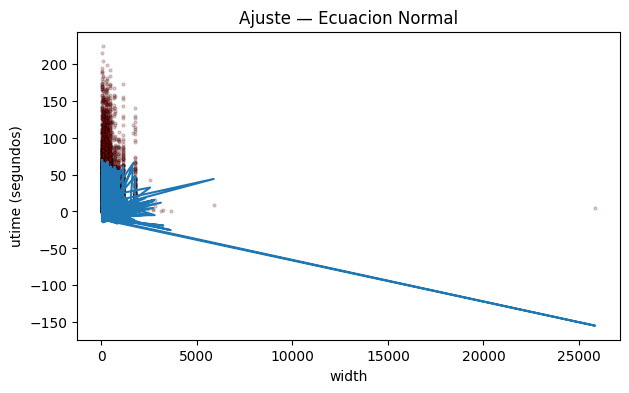

In [178]:
plotData(X[:, 1], y, 'width', 'utime (segundos)', 'Ajuste — Ecuacion Normal')
pyplot.plot(X[:, 1], np.dot(X, theta), '-')

### 100 Predicciones  Ecuación Normal


In [179]:
# Tomar las primeras 100 filas (sin normalizar)
X_test_ne = X[:100, :]
y_test_ne = y[:100]

# Predicciones con ecuacion normal
predicciones_ne = np.dot(X_test_ne, theta)

print('{:>5s}{:>12s}{:>14s}{:>12s}'.format('Ej', 'Real (s)', 'Predicho NE', 'Error'))
print('-' * 45)
for i in range(100):
    error = abs(y_test_ne[i] - predicciones_ne[i])
    print('{:>5d}{:>12.3f}{:>14.3f}{:>12.3f}'.format(i+1, y_test_ne[i], predicciones_ne[i], error))

error_medio_ne = np.mean(np.abs(y_test_ne - predicciones_ne))
print()
print('Error Absoluto Medio (MAE) - Ecuacion Normal: {:.4f} segundos'.format(error_medio_ne))

   Ej    Real (s)   Predicho NE       Error
---------------------------------------------
    1       0.612        -6.687       7.299
    2       0.980        -6.291       7.271
    3       1.216        -6.339       7.555
    4       1.692        -6.308       8.000
    5       3.456         4.401       0.945
    6       6.320        11.442       5.122
    7       0.728        -6.722       7.450
    8       0.944        -6.375       7.319
    9       1.476        -6.422       7.898
   10       1.964        -6.392       8.356
   11       3.968         4.318       0.350
   12       8.081        11.359       3.278
   13       0.896        -6.956       7.852
   14       1.332        -6.625       7.957
   15       2.080        -6.671       8.751
   16       2.932        -6.642       9.574
   17       5.724         4.068       1.656
   18      11.613        11.110       0.503
   19       0.824        -6.944       7.768
   20       1.244        -6.653       7.897
   21       2.012        -6.69


## Comparativa Final  100 Predicciones

Se comparan los tres modelos sobre las mismas 100 muestras del dataset

Valor real utime fila 0: 0.612 segundos

=== Comparativa de los 3 modelos (primeras 10 predicciones) ===
   Ej  Real (s)   GD Lineal GD Polinomial  Ec. Normal
-------------------------------------------------------
    1     0.612     -19.705        -9.469      -6.687
    2     0.980     -17.972        -8.123      -6.291
    3     1.216     -15.853        -6.475      -6.339
    4     1.692     -13.663        -4.772      -6.308
    5     3.456      -6.681         0.490       4.401
    6     6.320       2.687         7.785      11.442
    7     0.728     -18.915        -9.448      -6.722
    8     0.944     -17.225        -8.123      -6.375
    9     1.476     -15.106        -6.475      -6.422
   10     1.964     -12.917        -4.772      -6.392

=== Error Absoluto Medio (MAE) sobre 100 predicciones ===
  Descenso por el Gradiente (lineal):  13.1950 segundos
  Regresion Polinomial:                6.9680 segundos
  Ecuacion Normal:                     6.0778 segundos


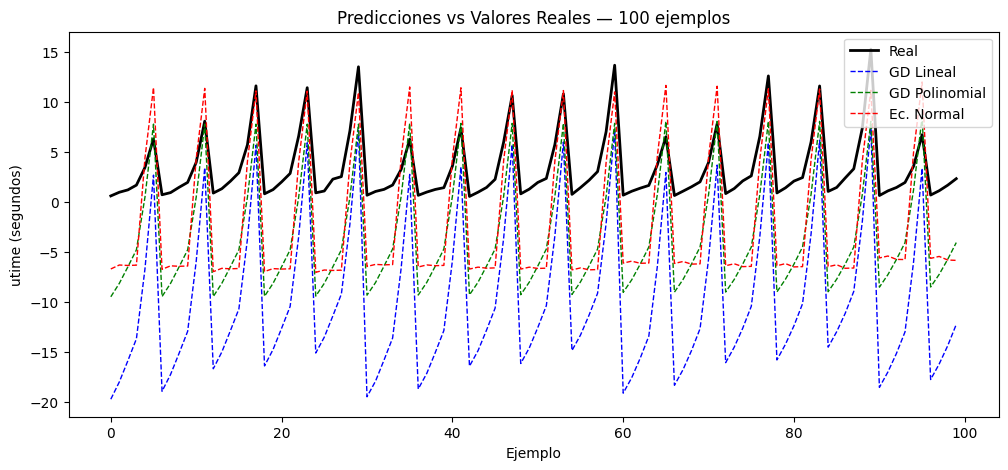

In [180]:
# Valor real del primer video para referencia
y_real_0 = df['utime'].iloc[0]
print('Valor real utime fila 0:', y_real_0, 'segundos')
print()

print('=== Comparativa de los 3 modelos (primeras 10 predicciones) ===')
print('{:>5s}{:>10s}{:>12s}{:>14s}{:>12s}'.format(
    'Ej', 'Real (s)', 'GD Lineal', 'GD Polinomial', 'Ec. Normal'))
print('-' * 55)
for i in range(10):
    print('{:>5d}{:>10.3f}{:>12.3f}{:>14.3f}{:>12.3f}'.format(
        i+1, y_test[i], predicciones_gd[i], predicciones_poly[i], predicciones_ne[i]))

print()
print('=== Error Absoluto Medio (MAE) sobre 100 predicciones ===')
print('  Descenso por el Gradiente (lineal):  {:.4f} segundos'.format(error_medio_gd))
print('  Regresion Polinomial:                {:.4f} segundos'.format(error_medio_poly))
print('  Ecuacion Normal:                     {:.4f} segundos'.format(error_medio_ne))

# Grafica comparativa
pyplot.figure(figsize=(12, 5))
indices = np.arange(100)
pyplot.plot(indices, y_test, 'k-', lw=2, label='Real')
pyplot.plot(indices, predicciones_gd, 'b--', lw=1, label='GD Lineal')
pyplot.plot(indices, predicciones_poly, 'g--', lw=1, label='GD Polinomial')
pyplot.plot(indices, predicciones_ne, 'r--', lw=1, label='Ec. Normal')
pyplot.xlabel('Ejemplo')
pyplot.ylabel('utime (segundos)')
pyplot.title('Predicciones vs Valores Reales — 100 ejemplos')
pyplot.legend()